Scanning DXF vertices for bounds...
Processing: h:\Project\2605\2026\3DEC\05_Geometry\Octree\RUN17\Run17_Octree_2018-3-75m_MineGrid.dxf
  Interpolating 47665 points onto grid...
Processing: h:\project\2605\GW\WT Interpretation\2026\NE Instability\interpretations\JAN 2018\20260724_LNX_NE_OCTREE_WT_OUTSIDE_WEDGE_JAN2018.dxf
  Interpolating 30238 points onto grid...
Exporting grid to H:\Project\2605\2026\3DEC\05_Geometry\Octree\RUN17\Z_Run17_minus_Z_Jan18HighWT.tif...


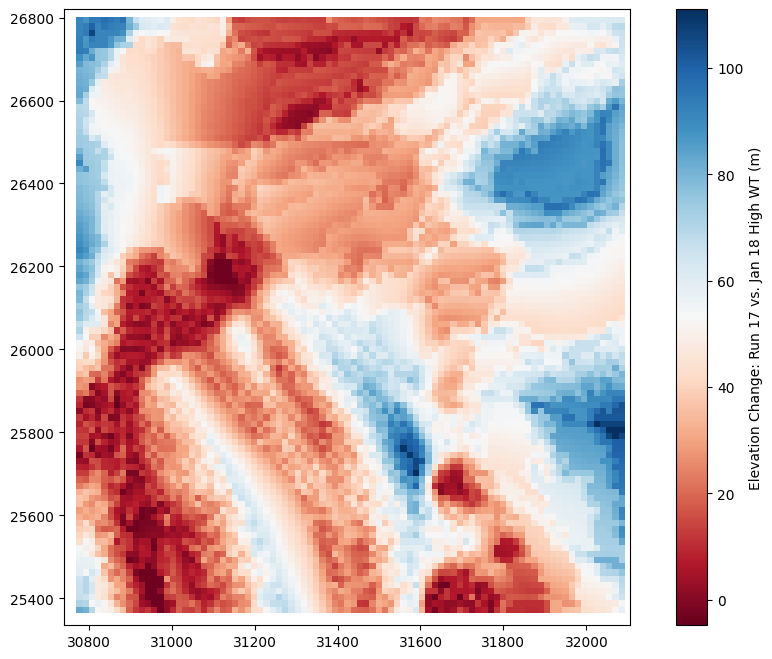

In [12]:
import ezdxf
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import rasterio
from rasterio.transform import from_origin

def _extract_entity_points(entity):
    """safely get points from valid geometric objects."""
    dxftype = entity.dxftype()
    pts = []
    
    if dxftype == '3DFACE':
        # if a face is a triangle, vtx3 often defaults to 0,0,0
        pts = [entity.dxf.vtx0, entity.dxf.vtx1, entity.dxf.vtx2, entity.dxf.vtx3]
        
    elif dxftype == 'MESH':
        pts = entity.vertices
        
    elif dxftype == 'POLYLINE':
        # pick approach depending on polyline flavor
        mode = entity.get_mode()
        if mode in ('AcDbPolyFaceMesh', 'AcDbPolygonMesh'):
            pts = [v.dxf.location for v in entity.vertices]
        else:
            pts = [v.dxf.xyz for v in entity.vertices]
            
    # filter out bad phantom zeros pulling the grid to the origin
    return [p for p in pts if not (abs(p[0]) < 1e-3 and abs(p[1]) < 1e-3)]

def get_combined_bounds(dxf_paths):
    """scan of vertices to find approximate site bounds."""
    x_mins, y_mins, x_maxs, y_maxs = [], [], [], []
    print("Scanning DXF vertices for bounds...")
    
    for path in dxf_paths:
        doc = ezdxf.readfile(path)
        msp = doc.modelspace()
        
        # only query vertices of primary surface entities
        for entity in msp.query('3DFACE MESH POLYLINE'):
            pts = _extract_entity_points(entity)
            if not pts:
                continue
            
            # update local bounds for this file
            arr = np.array(pts)
            if arr.size > 0:
                x_mins.append(arr[:, 0].min())
                y_mins.append(arr[:, 1].min())
                x_maxs.append(arr[:, 0].max())
                y_maxs.append(arr[:, 1].max())

    if not x_mins:
        raise ValueError("No valid coordinates extracted from selected DXF targets.")

    # add 10 unit buffer
    return (min(x_mins)-10, max(x_maxs)+10, min(y_mins)-10, max(y_maxs)+10)

def dxf_to_grid(dxf_path, bounds_info):
    """single-process extraction of dxf data and interpolation onto a grid."""
    x_min, x_max, y_min, y_max, pixel_size = bounds_info
    
    # create grid
    xi = np.arange(x_min, x_max, pixel_size)
    yi = np.arange(y_min, y_max, pixel_size)
    X_local, Y_local = np.meshgrid(xi, yi)
    
    print(f"Processing: {dxf_path}")
    doc = ezdxf.readfile(dxf_path)
    msp = doc.modelspace()
    points = []
    
    # extract vertices
    for entity in msp.query('3DFACE MESH POLYLINE'):
        pts = _extract_entity_points(entity)
        if pts:
            points.extend(pts)
            
    if not points:
        return np.full(X_local.shape, np.nan)
        
    pts = np.unique(np.array(points), axis=0)
    
    # linear interpolate dxf data onto grid
    print(f"  Interpolating {len(pts)} points onto grid...")
    z_grid = griddata((pts[:,0], pts[:,1]), pts[:,2], (X_local, Y_local), method='linear')
    
    # clear points from memory before returning
    del points
    del pts
    return z_grid

if __name__ == '__main__':
    dxf_Run17 = r"h:\Project\2605\2026\3DEC\05_Geometry\Octree\RUN17\Run17_Octree_2018-3-75m_MineGrid.dxf"
    dxf_Jan18HighWT = r"h:\project\2605\GW\WT Interpretation\2026\NE Instability\interpretations\JAN 2018\20260724_LNX_NE_OCTREE_WT_OUTSIDE_WEDGE_JAN2018.dxf"

    # use bounds from get_combined_bounds result
    pixel_size = 15
    x_min, x_max, y_min, y_max = get_combined_bounds([dxf_Run17, dxf_Jan18HighWT])
    bounds_info = (x_min, x_max, y_min, y_max, pixel_size)

    # process one at a time
    Z_Run17 = dxf_to_grid(dxf_Run17, bounds_info)
    Z_Jan18HighWT = dxf_to_grid(dxf_Jan18HighWT, bounds_info)

    # calculate elevation difference
    diff = Z_Run17 - Z_Jan18HighWT
    
    # export to geo-referenced tiff ---
    output_tiff = r"H:\Project\2605\2026\3DEC\05_Geometry\Octree\RUN17\Z_Run17_minus_Z_Jan18HighWT.tif"
    print(f"Exporting grid to {output_tiff}...")
    
    # rasterio needs arrays flipped or mapped from top-left origin
    # your coordinate system has y increasing upwards, but rasters read downwards
    transform = from_origin(x_min, y_max, pixel_size, pixel_size)
    diff_flipped = np.flipud(diff)
    
    with rasterio.open(
        output_tiff,
        'w',
        driver='GTiff',
        height=diff_flipped.shape[0],
        width=diff_flipped.shape[1],
        count=1,
        dtype=rasterio.float32,
        crs=None, # change to rasterio.crs.CRS.from_epsg(xxxx) if you know the local epsg code
        transform=transform,
        nodata=np.nan
    ) as dst:
        dst.write(diff_flipped.astype(rasterio.float32), 1)

    # isolate pixels containing actual comparative data for plot window
    valid_indices = np.argwhere(~np.isnan(diff))
    
    if valid_indices.size > 0:
        # separate coordinate boundaries based on data footprint
        ymin_idx, xmin_idx = valid_indices.min(axis=0)
        ymax_idx, xmax_idx = valid_indices.max(axis=0)
        
        # map layout arrays back to map units
        xi = np.arange(x_min, x_max, pixel_size)
        yi = np.arange(y_min, y_max, pixel_size)
        
        plot_xmin, plot_xmax = xi[xmin_idx], xi[xmax_idx]
        plot_ymin, plot_ymax = yi[ymin_idx], yi[ymax_idx]
        
        # add 2 pixel padding so drawing edge looks clean
        plot_xmin -= pixel_size * 2
        plot_xmax += pixel_size * 2
        plot_ymin -= pixel_size * 2
        plot_ymax += pixel_size * 2
    else:
        # skip cropping step if surfaces do not share shared space
        plot_xmin, plot_xmax = x_min, x_max
        plot_ymin, plot_ymax = y_min, y_max

    # visualize
    plt.figure(figsize=(12, 8))
    plt.imshow(diff, extent=(x_min, x_max, y_min, y_max), origin='lower', cmap='RdBu')
    plt.colorbar(label='Elevation Change: Run 17 vs. Jan 18 High WT (m)')
    
    # target map limits directly onto active area
    plt.xlim(plot_xmin, plot_xmax)
    plt.ylim(plot_ymin, plot_ymax)
    
    plt.show()